In [1]:
import numpy as np
import torch


seed = 1712
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
hidden_channels = 64
num_gnn_layers = 3

In [3]:
num_rounds = 500
num_epochs = 2
eval_round = num_rounds//10
batch_size = 32
num_train = 1000

num_test = 500
num_eval = 500

lr = 5e-4
step_size = num_rounds//10
gamma = 0.8

client_fraction = 0.6

num_epochs_cen = 1000
cen_lr = 5e-3

In [4]:
num_ue = 6
num_ap = 30
num_antenna = 1
tau=20; power_f=0.2; D=1; f=1900; Hb=15; Hm=1.65; d0=0.01;d1=0.05;


noise_p = 10**((-203.975+10*np.log10(20*10**6)+9)/10);
rho_d = power_f/noise_p
rho_p = power_f/noise_p

In [5]:
num_clients = num_ap
eval_round = eval_round if eval_round else num_rounds//10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
from Utils.data_gen import create_graph, build_loader
from torch_geometric.loader import DataLoader

import scipy.io
from Utils.data_gen_ldpc import build_cen_loader_ldpc, build_decen_loader_ldpc


file_name = f'dl_data_with_power_10000_{num_ue}_{num_ap}'
mat_data = scipy.io.loadmat('Data/' + file_name + '.mat')
beta_all = mat_data['betas']
gamma_all = mat_data['Gammas']
power_all = mat_data['power']/rho_d
phi_all = mat_data['Phii_cf'].transpose(0, 2, 1)
opt_train_rates = mat_data['R_cf_opt_min'][0]

label_all = power_all

perm = np.random.RandomState(seed).permutation(beta_all.shape[0])
train_idx = perm[:num_train]
test_idx  = perm[num_train: num_train + num_test]


## Decentralized Data
# Beta_all, Phi_all = beta_all[train_idx], phi_all[train_idx]
# train_data = create_graph(Beta_all, Phi_all, beta_mean, beta_std, 'het')
# train_loader = build_loader(train_data, batch_size, seed=seed, drop_last=True)

# Beta_test, Phi_test = beta_all[test_idx], phi_all[test_idx]
# test_data = create_graph(Beta_test, Phi_test, beta_mean, beta_std, 'het')
# test_loader = build_loader(test_data, batch_size, seed=seed, drop_last=True)

# train_data, train_loader = build_decen_loader_ldpc(
#     beta_all[train_idx],
#     gamma_all[train_idx], 
#     label_all[train_idx],
#     phi_all[train_idx],
#     batch_size, seed=seed
# )
# test_data, test_loader = build_decen_loader_ldpc(
#     beta_all[test_idx], 
#     gamma_all[test_idx],
#     label_all[test_idx],
#     phi_all[test_idx], 
#     batch_size, seed=seed
# )



## Centralized Data
train_data_cen, train_loader_cen = build_cen_loader_ldpc(
    beta_all[train_idx],
    gamma_all[train_idx], 
    label_all[train_idx],
    phi_all[train_idx],
    batch_size, isShuffle=True
)
test_data_cen, test_loader_cen = build_cen_loader_ldpc(
    beta_all[test_idx], 
    gamma_all[test_idx],
    label_all[test_idx],
    phi_all[test_idx], 
    batch_size
)

c:\Users\wine\anaconda3\envs\new-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\wine\Giang\Code\Viet\new\densityevolution\GNN_FL_cf_mMIMO\Utils\data_gen_ldpc.py:152: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  data.y = torch.tensor([eta_single_all], dtype=torch.float32).to(device)


In [7]:
from Models.LDPC_inspired_GNN import LDPCGNN
from torch.optim.lr_scheduler import StepLR

In [8]:
torch.set_default_dtype(torch.float32) 

num_gnn_layers = 3
cen_lr = 5e-3 # 5e-3  the the best results
batch_size = 32
hidden_channels = 64 # min 32

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = train_data_cen[0]   
dim_dict = {
    'VN': data['VN'].x.size(-1),
    'CN': data['CN'].x.size(-1),
    'edge': data['CN', 'to', 'VN'].edge_attr.size(-1),
}

metadata = [
    ('VN', 'to', 'CN'),
    ('CN', 'to', 'VN'),
]
criterion = torch.nn.BCEWithLogitsLoss()


In [10]:
from Utils.decentralized_train import FedAvg
fed = FedAvg(client_fraction=client_fraction)

In [11]:
def lr_factor(round_idx, warmup_rounds, gamma):
    """Round-wise LR factor in (0, 1]. round_idx is 0-based."""
    if round_idx < warmup_rounds:
        # linear warmup
        return float(round_idx + 1) / warmup_rounds
    else:
        # slow exponential decay
        return gamma ** (round_idx - warmup_rounds)

In [12]:
data = train_data_cen[0]   
dim_dict = {
    'VN': data['VN'].x.size(-1),
    'CN': data['CN'].x.size(-1),
    'edge': data['CN', 'to', 'VN'].edge_attr.size(-1),
}

metadata = [
    ('VN', 'to', 'CN'),
    ('CN', 'to', 'VN'),
]

In [24]:
dim_dict

{'VN': 20, 'CN': 1, 'edge': 2}

In [13]:
from Models.LDPC_new import LDPCPowerGNN
from Utils.MTAdam import MTAdam, ldpc_loss_mtadam, ldpc_train_mtadam, ldpc_eval_mtadam

model = LDPCPowerGNN(
    dim_dict['VN'], dim_dict['CN'], dim_dict['edge'],
    message_dim=32,
    hidden=32,
    num_iter=2,
    gamma_idx=1,
    power_limit=rho_d
).to(device)
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
optimizer = MTAdam(
    model.parameters(),
    lr=cen_lr, betas=(0.9, 0.999, 0.99), eps=1e-8,
                 weight_decay=0
)


# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer, step_size=num_epochs_cen//10, gamma=0.8
# )

In [14]:
from Utils.MTAdam import beta3_schedule, update_alpha
num_epochs_cen = 1000
alpha = 1e-11
alpha_power = 1e-6     
alpha_rate  = 1.0
beta3_lo, beta3_hi = 0.5, 0.9
gamma_idx = 1
power_limit = 1.0
target_rate = 1.0
all_p_c_loss      = []
all_p_c_test      = []
all_r_c_loss      = []
all_r_c_test      = []
all_rate          = []
all_rate_test     = []
all_rate_viol     = []
all_rate_viol_test= []
eval_epochs_cen = num_epochs_cen//10 if num_epochs_cen//10 else 1

In [ ]:
for epoch in range(num_epochs_cen):
    epoch_ratio = epoch / max(1, (2 * num_epochs_cen // 3))

    # === update beta3 (MTAdam betas[2]) ===
    beta3_t = beta3_schedule(
        epoch,
        num_epochs_cen,
        beta3_start=beta3_lo,
        beta3_end=beta3_hi
    )

    for group in optimizer.param_groups:
        beta1, beta2, _ = group["betas"]
        group["betas"] = (beta1, beta2, beta3_t)

    # === train 1 epoch ===
    train_task_loss, train_p_c_loss, train_r_c_loss = ldpc_train_mtadam(
        epoch_ratio,
        train_loader_cen, model, optimizer,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna,
        alpha_power    = alpha_power,
        alpha_rate     = alpha_rate,
        beta3          = beta3_t,
        gamma_idx=gamma_idx,
        power_limit=power_limit,
        target_rate=target_rate,
        rate_mode='min',
    )

    # === eval trên train set ===
    train_rate, train_p_c_loss_eval, train_r_c_loss_eval = ldpc_eval_mtadam(
        train_loader_cen, model,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna,
        gamma_idx=gamma_idx,
        power_limit=power_limit,
    )

    # === eval trên test set ===
    test_rate, test_p_c_loss_eval, test_r_c_loss_eval = ldpc_eval_mtadam(
        test_loader_cen, model,
        tau=tau, rho_p=rho_p, rho_d=rho_d, num_antenna=num_antenna,
        gamma_idx=gamma_idx,
        power_limit=power_limit,
    )

    # === update alpha dựa trên power-constraint loss của epoch train ===
    alpha = update_alpha(
        alpha_old=alpha,
        c_loss_epoch=train_p_c_loss,
        c_high=1e-2, c_low=1e-4,
        up_factor=1.05, down_factor=0.9,
        alpha_min=1e-7, alpha_max=1e-6
    )

    # === lưu lịch sử ===
    all_p_c_loss.append(train_p_c_loss_eval)
    all_p_c_test.append(test_p_c_loss_eval)
    all_r_c_loss.append(train_r_c_loss_eval)
    all_r_c_test.append(test_r_c_loss_eval)
    all_rate.append(train_rate)
    all_rate_test.append(test_rate)

    # === 7) Log ===
    if epoch % 1 == 0:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs_cen} | "
            f"beta3={beta3_t:.4f} | "
            f"alpha_power={alpha_power:.4e} | "
            f"Train Task Loss: {train_task_loss:.4f} | "
            f"Train Power C Loss: {train_p_c_loss_eval:.4e} | "
            f"Train Rate C Loss: {train_r_c_loss_eval:.4e} | "
            f"Train Rate: {train_rate:.4f} | "
            f"Test Rate: {test_rate:.4f} | "
            f"Test Power C Loss: {test_p_c_loss_eval:.4e} | "
            f"Test Rate C Loss: {test_r_c_loss_eval:.4e}"
        )

Epoch 001/1000 | beta3=0.5000 | alpha_power=9.0000e-07 | Train Task Loss: -0.0435 | Train Power C Loss: 0.0000e+00 | Train Rate C Loss: 6.0574e-01 | Train Rate: 0.2645 | Train Rate Viol: 98.50% | Test Rate: 0.2609 | Test Power C Loss: 0.0000e+00 | Test Rate C Loss: 6.1387e-01 | Test Rate Viol: 98.60%
Epoch 002/1000 | beta3=0.5000 | alpha_power=8.1000e-07 | Train Task Loss: -0.5060 | Train Power C Loss: 0.0000e+00 | Train Rate C Loss: 2.3048e-01 | Train Rate: 0.6909 | Train Rate Viol: 75.60% | Test Rate: 0.7229 | Test Power C Loss: 0.0000e+00 | Test Rate C Loss: 2.0692e-01 | Test Rate Viol: 73.40%
Epoch 003/1000 | beta3=0.5000 | alpha_power=7.2900e-07 | Train Task Loss: -0.7021 | Train Power C Loss: 0.0000e+00 | Train Rate C Loss: 9.4432e-02 | Train Rate: 1.0161 | Train Rate Viol: 43.10% | Test Rate: 1.0423 | Test Power C Loss: 0.0000e+00 | Test Rate C Loss: 8.4261e-02 | Test Rate Viol: 42.40%
Epoch 004/1000 | beta3=0.5000 | alpha_power=6.5610e-07 | Train Task Loss: -1.0368 | Train Powe

# Convergence

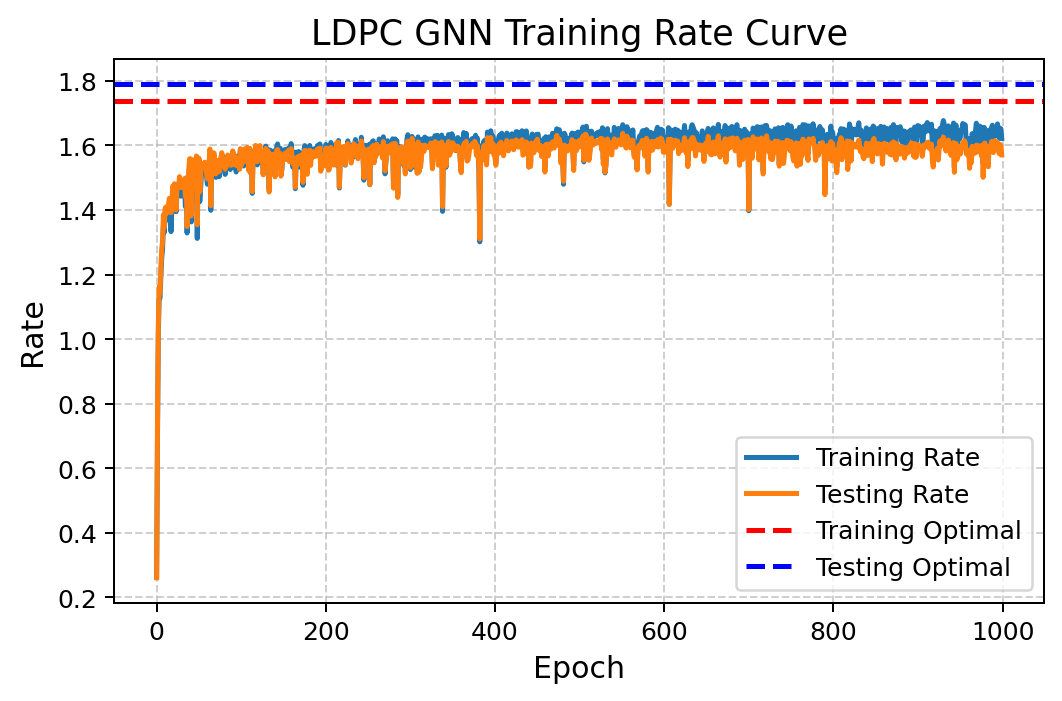

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4), dpi=180)
plt.plot(all_rate, label='Training Rate', linewidth=2)
plt.plot(all_rate_test, label='Testing Rate', linewidth=2)
plt.axhline(y=np.mean(opt_train_rates[train_idx]), linewidth=2, color='r', linestyle='--', label='Training Optimal')
plt.axhline(y=np.mean(opt_train_rates[test_idx]), linewidth=2, color='b', linestyle='--', label='Testing Optimal')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.title('LDPC GNN Training Rate Curve', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

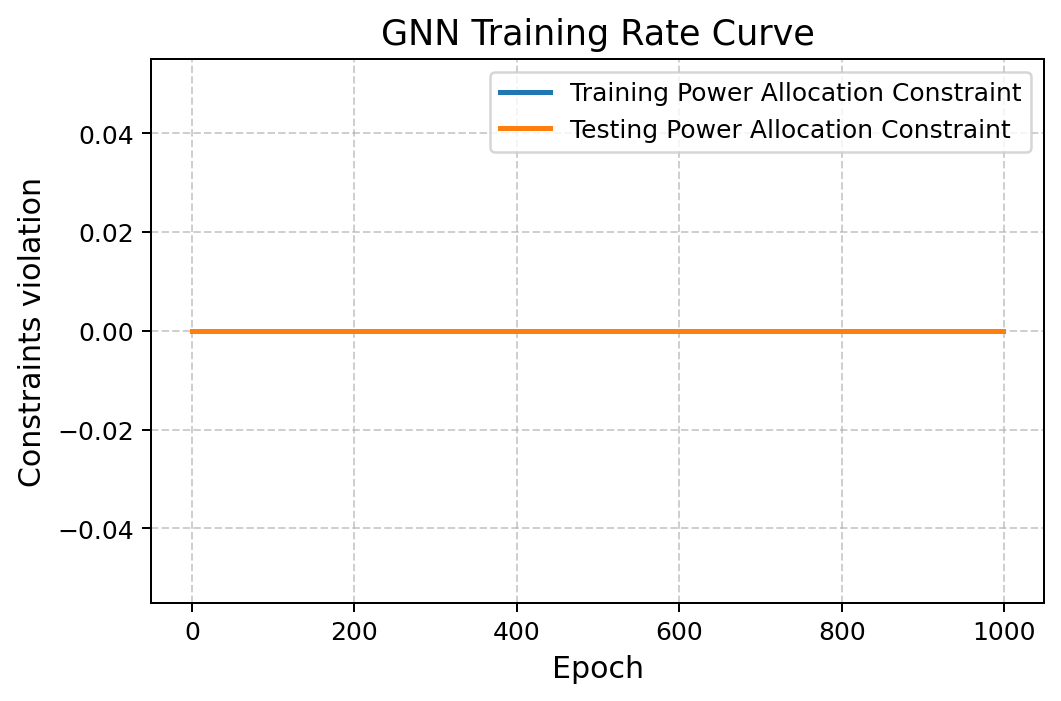

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# chuyển list -> numpy array rồi scale
loss_arr = np.array(all_p_c_loss) / 1e6
test_arr = np.array(all_p_c_test) / 1e6

plt.figure(figsize=(6,4), dpi=180)
plt.plot(loss_arr, label='Training Power Allocation Constraint', linewidth=2)
plt.plot(test_arr, label='Testing Power Allocation Constraint', linewidth=2)
# plt.axhline(y=np.mean(opt_train_rates[train_idx]), linewidth=2, color='r', linestyle='--', label='Training Optimal')
# plt.axhline(y=np.mean(opt_train_rates[test_idx]), linewidth=2, color='b', linestyle='--', label='Testing Optimal')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Constraints violation', fontsize=12)
plt.title('GNN Training Rate Curve', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

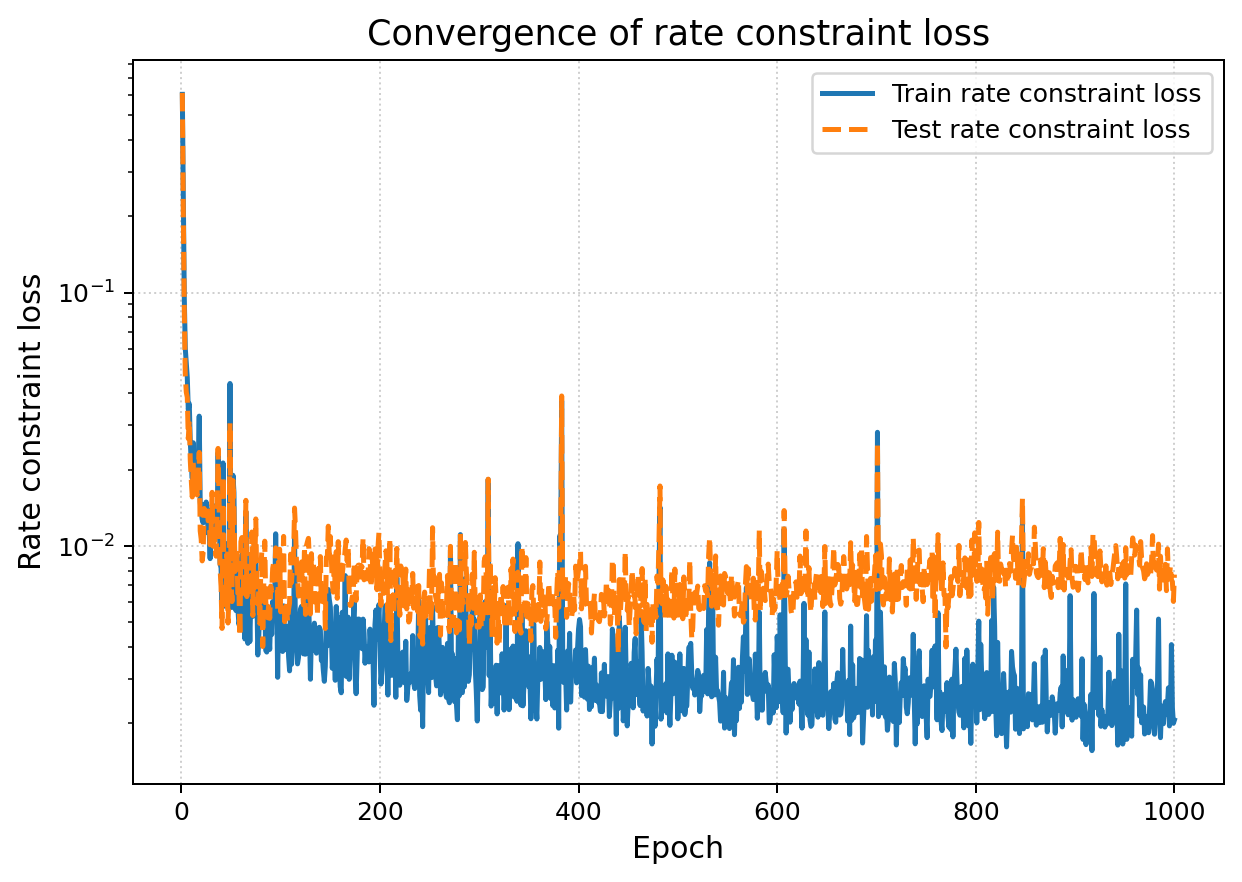

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Giả sử 2 list này đã được bạn fill trong vòng lặp training
# all_r_c_loss      = [...]   # train rate constraint loss per epoch
# all_r_c_test      = [...]   # test  rate constraint loss per epoch

epochs = np.arange(1, len(all_r_c_loss) + 1)

plt.figure(figsize=(7, 5), dpi=180)

plt.plot(epochs, all_r_c_loss, label='Train rate constraint loss', linewidth=2)
plt.plot(epochs, all_r_c_test, label='Test rate constraint loss', linewidth=2, linestyle='--')

# Nếu loss trải dài nhiều bậc, bật log-scale trục y cho dễ nhìn
plt.yscale('log')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Rate constraint loss', fontsize=12)
plt.title('Convergence of rate constraint loss', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# Count constraints violation

In [20]:
import torch
from Utils.MTAdam import _scatter_sum
def count_constraint_violations_batch(
    graphData,
    edge_attr_dict,
    edge_index_dict,
    gamma_idx=1,
    edge_key=('CN', 'to', 'VN'),
    power_limit=1.0,
    rhod=1.0,
):
    """
    Đếm số AP (CN) vi phạm ràng buộc:
        sum_k p_{mk} * gamma_{mk} > power_limit

    Trả về:
        num_violated    : số AP vi phạm
        total_ap        : tổng số AP trong batch
        frac_violated   : tỉ lệ vi phạm
        S_per_ap        : tensor [N_ap] giá trị sum_k p_{mk} * gamma_{mk}
    """
    # Tổng số AP (CN) trong batch (gộp tất cả graphs)
    n_ap_total = graphData['CN'].x.size(0)

    # Edge index & edge features
    edge_index = edge_index_dict[edge_key]   # [2, E]
    cn_idx = edge_index[0]                   # AP index cho mỗi edge

    edge_attr = edge_attr_dict[edge_key]     # [E, F]
    p     = edge_attr[:, -1]                 # power per edge
    gamma = edge_attr[:, gamma_idx]/rhod          # gamma per edge

    # S_m = sum_k p_{mk} * gamma_{mk} cho từng AP m
    weighted = p * gamma                     # [E]
    S_per_ap = _scatter_sum(weighted, cn_idx, dim_size=n_ap_total)  # [N_ap]

    # Vi phạm nếu S_m > power_limit + tol
    violation_mask = S_per_ap > (power_limit)
    num_violated   = violation_mask.sum().item()
    total_ap       = n_ap_total
    frac_violated  = num_violated / total_ap if total_ap > 0 else 0.0

    return num_violated, total_ap, frac_violated, S_per_ap

In [21]:
model.eval()

total_ap_all        = 0
total_violated_all  = 0
S_all_list          = []

for batch in train_loader_cen:
    batch = batch.to(device)
    # chạy model để có edge_attr_dict mới (p đã được GNN sinh)
    x_dict, edge_attr_dict, edge_index_dict = model(batch)

    num_violated, total_ap, frac, S_per_ap = count_constraint_violations_batch(
        batch,
        edge_attr_dict,
        edge_index_dict,
        gamma_idx=gamma_idx,
        edge_key=('CN', 'to', 'VN'),
        power_limit=power_limit,
        rhod=rho_d,
    )

    total_ap_all       += total_ap
    total_violated_all += num_violated
    S_all_list.append(S_per_ap.cpu())

if len(S_all_list) > 0:
    S_all = torch.cat(S_all_list, dim=0)
    mean_S = S_all.mean().item()
    min_S  = S_all.min().item()
    max_S  = S_all.max().item()
else:
    mean_S = min_S = max_S = 0.0

frac_all = total_violated_all / total_ap_all if total_ap_all > 0 else 0.0

print(f"[Constraint check] Violations: {total_violated_all}/{total_ap_all} APs "
        f"({frac_all*100:.2f}%)")
print(f"[Constraint check] S_per_ap stats: mean={mean_S:.4f}, "
        f"min={min_S:.4f}, max={max_S:.4f}")

[Constraint check] Violations: 0/30000 APs (0.00%)
[Constraint check] S_per_ap stats: mean=0.0000, min=0.0000, max=0.0000
